# LSGAN para ArtBench-10 (32×32)

Notebook com uma implementação de **LSGAN** adaptada ao teu problema:
- ArtBench-10
- imagens RGB 32×32
- Generator + Discriminator
- treino
- geração de amostras
- FID/KID opcionais
- bloco opcional para múltiplas seeds


In [1]:
import os
import sys
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torchvision import transforms, utils as vutils

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

from __future__ import annotations

import sys
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms 
from torchvision.utils import make_grid
import torchvision.utils as vutils


Torch version: 2.5.1+cu121
CUDA available: True


In [2]:
SEED = 42
BATCH_SIZE = 64
IMAGE_SIZE = 32
NC = 3
NZ = 100
NGF = 64
NDF = 64
NUM_EPOCHS = 50
LR = 2e-4
BETA1 = 0.5
BETA2 = 0.999
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_PATHS = [
    "/content/ArtBench-10",
    "./ArtBench-10",
    "../ArtBench-10",
]
HELPER_PATHS = [
    "/content/TP1-alunos-src-only",
    "./TP1-alunos-src-only",
    "../TP1-alunos-src-only",
]

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

set_seed(SEED)
DATASET_PATH = find_first_existing(DATASET_PATHS)
HELPER_PATH = find_first_existing(HELPER_PATHS)

print("Device:", DEVICE)
print("DATASET_PATH:", DATASET_PATH)
print("HELPER_PATH:", HELPER_PATH)

if HELPER_PATH is not None and HELPER_PATH not in sys.path:
    sys.path.append(HELPER_PATH)


Device: cuda
DATASET_PATH: ./ArtBench-10
HELPER_PATH: ./TP1-alunos-src-only


In [3]:
def find_project_root(start: Path, markers: list[str], max_levels: int = 6) -> Path:
    """Sobe na árvore de pastas até encontrar uma pasta que contenha todos os markers."""
    path = start
    for _ in range(max_levels):
        if all((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise RuntimeError(
        f"PROJECT_ROOT não encontrado a partir de {start}.\n"
        "Estrutura esperada: pasta com 'ArtBench-10/' e 'TP1-alunos-src-only/'."
    )

PROJECT_ROOT      = find_project_root(Path(".").resolve(), ["ArtBench-10", "TP1-alunos-src-only"])
SCRIPTS_DIR       = PROJECT_ROOT / "TP1-alunos-src-only" / "scripts"
KAGGLE_ROOT       = PROJECT_ROOT / "ArtBench-10"
TRAINING_CSV_PATH = PROJECT_ROOT / "TP1-alunos-src-only" / "student_start_pack" / "training_20_percent.csv"

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("SCRIPTS_DIR    =", SCRIPTS_DIR)
print("KAGGLE_ROOT    =", KAGGLE_ROOT)
print("TRAINING CSV   =", TRAINING_CSV_PATH)

assert SCRIPTS_DIR.exists(), f"Não existe: {SCRIPTS_DIR}"
assert KAGGLE_ROOT.exists(), f"Não existe: {KAGGLE_ROOT}"
assert TRAINING_CSV_PATH.exists(), f"Não existe: {TRAINING_CSV_PATH}"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))


PROJECT_ROOT   = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1
SCRIPTS_DIR    = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\TP1-alunos-src-only\scripts
KAGGLE_ROOT    = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\ArtBench-10
TRAINING CSV   = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\TP1-alunos-src-only\student_start_pack\training_20_percent.csv


In [4]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_dataset_completo = hf_ds["train"]

print("Número total de imagens de treino:", len(train_dataset_completo))
print("Colunas:", train_dataset_completo.column_names)

label_feature = train_dataset_completo.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Classes:", class_names)

Dataset source: kaggle root='D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\ArtBench-10'
Número total de imagens de treino: 50000
Colunas: ['image', 'label']
Número de classes: 10
Classes: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [5]:
transform=transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform is not None else img
        return x, y, real_idx

def denorm(x):
    '''inverte a normalização Normalize(0.5, 0.5, 0.5) que foi aplicada no transform. As imagens foram guardadas em [-1, 1] (necessário para o Tanh() do gerador), e esta função converte de volta para [0, 1] para poder visualizar com matplotlib.'''
    return (x * 0.5 + 0.5).clamp(0, 1)

In [6]:
INDEX_COLUMN = "train_id_original"

def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    ids = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if index_column not in (reader.fieldnames or []):
            raise ValueError(f"Coluna {index_column!r} não encontrada. Disponíveis: {reader.fieldnames}")
        for row in reader:
            value = str(row.get(index_column, "")).strip()
            if value:
                ids.append(int(value))
    if len(ids) == 0:
        raise ValueError("Não foram lidos IDs do CSV.")
    return ids

train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, INDEX_COLUMN)

print("Número de IDs lidos do CSV:", len(train_ids_from_csv))
print("Primeiros 10 IDs:", train_ids_from_csv[:10])

Número de IDs lidos do CSV: 10000
Primeiros 10 IDs: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]


In [7]:
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.


In [8]:
train_subset = HFDatasetTorch(train_dataset_completo, transform=transform, indices=train_ids_from_csv)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Tamanho do subset:", len(train_subset))
print("Número de batches:", len(train_loader))


Tamanho do subset: 10000
Número de batches: 157


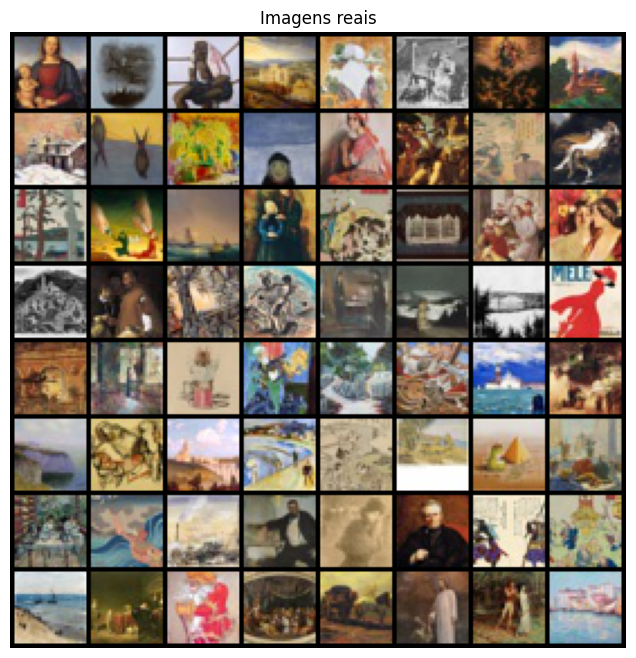

In [9]:
real_batch = next(iter(train_loader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Imagens reais")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0][:64], padding=2, normalize=True).cpu(), (1, 2, 0)))
plt.show()


In [10]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [11]:
class Generator(nn.Module):
    def __init__(self, nz=NZ, ngf=NGF, nc=NC):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(self, nc=NC, ndf=NDF):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.classifier = nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.view(-1, 1)


In [12]:
netG = Generator().to(DEVICE)
netD = Discriminator().to(DEVICE)

netG.apply(weights_init)
netD.apply(weights_init)

criterion = nn.MSELoss()
optimizerD = optim.Adam(netD.parameters(), lr=1e-4, betas=(BETA1, BETA2))
optimizerG = optim.Adam(netG.parameters(), lr=2e-4, betas=(BETA1, BETA2))

fixed_noise = torch.randn(64, NZ, 1, 1, device=DEVICE)
print(netG)
print()
print(netD)


Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

Discriminator(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(

In [13]:
def make_targets(size, value, device):
    return torch.full((size, 1), value, device=device)

def show_generated_images(generator, noise=None, n=64, title="Amostras geradas"):
    generator.eval()
    with torch.no_grad():
        if noise is None:
            noise = torch.randn(n, NZ, 1, 1, device=DEVICE)
        fake = generator(noise).detach().cpu()
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title(title)
    plt.imshow(np.transpose(vutils.make_grid(fake, padding=2, normalize=True), (1, 2, 0)))
    plt.show()


In [14]:
img_list = []
G_losses = []
D_losses = []
iters = 0

print("A iniciar treino LSGAN...")

for epoch in range(NUM_EPOCHS):
    for i, batch in enumerate(train_loader):
        real_imgs = batch[0].to(DEVICE)
        b_size = real_imgs.size(0)

        # -------------------------
        # Treinar Discriminator
        # -------------------------
        netD.zero_grad()

        real_targets = make_targets(b_size, 1.0, DEVICE)
        fake_targets = make_targets(b_size, 0.0, DEVICE)

        out_real = netD(real_imgs)
        loss_real = criterion(out_real, real_targets)

        noise = torch.randn(b_size, NZ, 1, 1, device=DEVICE)
        fake_imgs = netG(noise)

        out_fake = netD(fake_imgs.detach())
        loss_fake = criterion(out_fake, fake_targets)

        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        optimizerD.step()

        # -------------------------
        # Treinar Generator
        # -------------------------
        netG.zero_grad()

        out_fake_for_G = netD(fake_imgs)
        loss_G = 0.5 * criterion(out_fake_for_G, real_targets)
        loss_G.backward()
        optimizerG.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

        if (i % 50 == 0) or (i == len(train_loader) - 1):
            print(
                f"[Epoch {epoch+1:03d}/{NUM_EPOCHS:03d}] "
                f"[Batch {i:04d}/{len(train_loader)-1:04d}] "
                f"Loss_D: {loss_D.item():.4f} | Loss_G: {loss_G.item():.4f}"
            )

        if (iters % 500 == 0) or ((epoch == NUM_EPOCHS - 1) and (i == len(train_loader) - 1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

print("Treino terminado.")


A iniciar treino LSGAN...
[Epoch 001/050] [Batch 0000/0156] Loss_D: 0.9770 | Loss_G: 0.6703
[Epoch 001/050] [Batch 0050/0156] Loss_D: 0.4351 | Loss_G: 2.7799
[Epoch 001/050] [Batch 0100/0156] Loss_D: 0.2835 | Loss_G: 2.3357
[Epoch 001/050] [Batch 0150/0156] Loss_D: 0.1089 | Loss_G: 1.2984
[Epoch 001/050] [Batch 0156/0156] Loss_D: 0.4155 | Loss_G: 0.0406
[Epoch 002/050] [Batch 0000/0156] Loss_D: 0.8271 | Loss_G: 4.4800
[Epoch 002/050] [Batch 0050/0156] Loss_D: 0.5034 | Loss_G: 0.0186
[Epoch 002/050] [Batch 0100/0156] Loss_D: 0.1296 | Loss_G: 0.4661
[Epoch 002/050] [Batch 0150/0156] Loss_D: 0.1991 | Loss_G: 0.2675
[Epoch 002/050] [Batch 0156/0156] Loss_D: 0.2189 | Loss_G: 0.9045
[Epoch 003/050] [Batch 0000/0156] Loss_D: 0.1273 | Loss_G: 0.9759
[Epoch 003/050] [Batch 0050/0156] Loss_D: 0.1378 | Loss_G: 1.2352
[Epoch 003/050] [Batch 0100/0156] Loss_D: 0.0769 | Loss_G: 0.8698
[Epoch 003/050] [Batch 0150/0156] Loss_D: 0.1029 | Loss_G: 0.4082
[Epoch 003/050] [Batch 0156/0156] Loss_D: 0.1523 |

KeyboardInterrupt: 

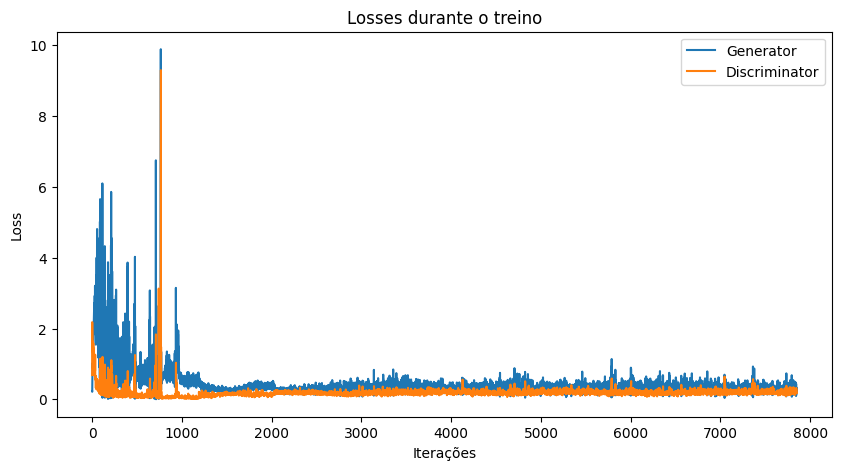

In [ ]:
LR_G = 2e-4   # usado no optimizerG
LR_D = 1e-4   # usado no optimizerD

plt.figure(figsize=(10, 5))
plt.title(f"Generator and Discriminator Loss During Training — seed {SEED} — lr_G {LR_G} lr_D {LR_D} — nz {NZ}")
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.xlabel("Iterações")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(f"losses_seed_{SEED}_lr_G{LR_G}_lr_D{LR_D}_latente{NZ}.png", dpi=300, bbox_inches="tight")
plt.show()


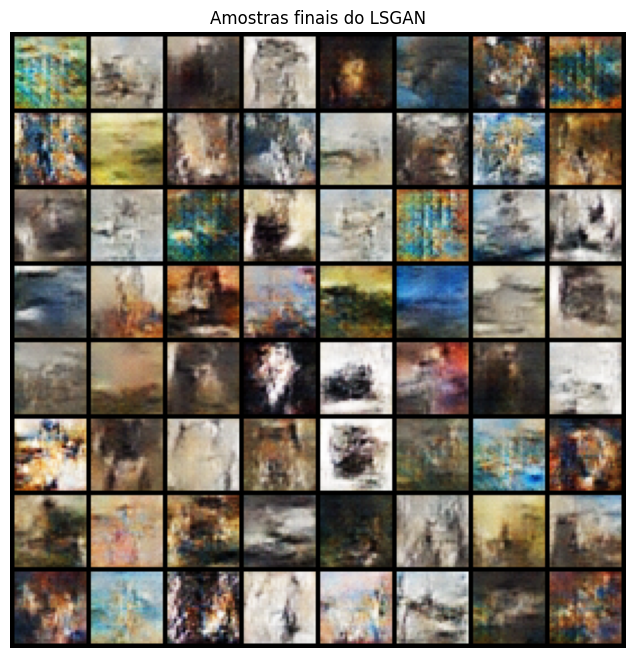

In [ ]:
from torchvision.utils import save_image

SAMPLES_DIR = PROJECT_ROOT / "results" / "samples" / f"lsgan_seed_{SEED}_lr_G{LR_G}_lr_D{LR_D}_latente{NZ}"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

netG.eval()
with torch.no_grad():
    noise = torch.randn(64, NZ, 1, 1, device=DEVICE)
    fake_images_display = netG(noise).cpu()
    fake_images_display = denorm(fake_images_display)

# guardar grelha de amostras
grid = vutils.make_grid(fake_images_display, nrow=8, padding=2)
save_image(grid, SAMPLES_DIR / "grid.png")

plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title(f"Amostras finais do LSGAN — seed {SEED}")
plt.tight_layout()
plt.savefig(SAMPLES_DIR / "samples_display.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Amostras guardadas em: {SAMPLES_DIR.resolve()}")


In [ ]:
# Comparação lado a lado: imagens reais vs geradas
real_batch_display = next(iter(train_loader))

plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(
    vutils.make_grid(real_batch_display[0].to(DEVICE)[:64], padding=5, normalize=True).cpu(),
    (1, 2, 0)
))

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))

plt.tight_layout()
plt.savefig(f"real_vs_fake_seed_{SEED}_lr_G{LR_G}_lr_D{LR_D}_latente{NZ}.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
RESULTS_DIR = PROJECT_ROOT / "results"
CKPT_DIR = RESULTS_DIR / "checkpoints"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(netG.state_dict(), CKPT_DIR / f"lsgan_netG_seed{SEED}_lr_G{LR_G}_lr_D{LR_D}_latente{NZ}.pt")
torch.save(netD.state_dict(), CKPT_DIR / f"lsgan_netD_seed{SEED}_lr_G{LR_G}_lr_D{LR_D}_latente{NZ}.pt")

print(f"Checkpoints guardados em: {CKPT_DIR.resolve()}")


Checkpoint guardado.


In [ ]:
def generate_fake_images(generator, num_images=5000, batch_size=128, nz=NZ, device=DEVICE):
    generator.eval()
    fake_images = []
    total = 0

    with torch.no_grad():
        while total < num_images:
            current_bs = min(batch_size, num_images - total)
            z = torch.randn(current_bs, nz, 1, 1, device=device)
            fake = generator(z)
            fake_images.append(fake.cpu())
            total += current_bs

    return torch.cat(fake_images, dim=0)[:num_images]

def collect_real_images(dataloader, num_images=5000):
    all_imgs = []
    total = 0
    for batch in dataloader:
        imgs = batch[0]
        all_imgs.append(imgs.cpu())
        total += imgs.size(0)
        if total >= num_images:
            break
    return torch.cat(all_imgs, dim=0)[:num_images]

fake_5000 = generate_fake_images(netG, num_images=5000, batch_size=BATCH_SIZE)
real_5000 = collect_real_images(train_loader, num_images=5000)

print("fake_5000:", tuple(fake_5000.shape))
print("real_5000:", tuple(real_5000.shape))


fake_5000: (5000, 3, 32, 32)
real_5000: (5000, 3, 32, 32)


In [ ]:
import json

# Instalar se necessário:
# !pip install torchmetrics[image]

try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.kid import KernelInceptionDistance
    TORCHMETRICS_AVAILABLE = True
except Exception:
    TORCHMETRICS_AVAILABLE = False
    print("torchmetrics não disponível. Instala com: pip install torchmetrics[image]")

def to_01(x):
    return ((x + 1) / 2).clamp(0, 1)

def compute_fid(real_imgs, fake_imgs, device=DEVICE, batch_size=128):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    for i in range(0, len(real_imgs), batch_size):
        fid.update(to_01(real_imgs[i:i+batch_size]).to(device), real=True)
    for i in range(0, len(fake_imgs), batch_size):
        fid.update(to_01(fake_imgs[i:i+batch_size]).to(device), real=False)
    return float(fid.compute().item())

def compute_kid(real_imgs, fake_imgs, device=DEVICE, subset_size=100, num_subsets=50):
    scores = []
    n_real = real_imgs.size(0)
    n_fake = fake_imgs.size(0)

    for _ in range(num_subsets):
        idx_real = torch.randperm(n_real)[:subset_size]
        idx_fake = torch.randperm(n_fake)[:subset_size]

        real_subset = to_01(real_imgs[idx_real]).to(device)
        fake_subset = to_01(fake_imgs[idx_fake]).to(device)

        kid = KernelInceptionDistance(subset_size=subset_size, normalize=True).to(device)
        kid.update(real_subset, real=True)
        kid.update(fake_subset, real=False)
        kid_mean, _ = kid.compute()
        scores.append(float(kid_mean.item()))

    return float(np.mean(scores)), float(np.std(scores))

if TORCHMETRICS_AVAILABLE:
    fid_value = compute_fid(real_5000, fake_5000)
    kid_mean, kid_std = compute_kid(real_5000, fake_5000)

    print(f"FID: {fid_value:.4f}")
    print(f"KID: {kid_mean:.6f} ± {kid_std:.6f}")

    metrics = {
        "fid": fid_value,
        "kid_mean": kid_mean,
        "kid_std": kid_std,
    }

    json_path = RESULTS_DIR / f"metrics_lsgan_seed{SEED}_lr_G{LR_G}_lr_D{LR_D}_latente{NZ}.json"
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump({
            "seed": SEED,
            "metrics": metrics,
            "G_losses": G_losses,
            "D_losses": D_losses,
        }, f, indent=2)
    print(f"Métricas guardadas em: {json_path.resolve()}")


OutOfMemoryError: CUDA out of memory. Tried to allocate 5.00 GiB. GPU 0 has a total capacity of 2.00 GiB of which 1.19 GiB is free. Of the allocated memory 378.48 MiB is allocated by PyTorch, and 29.52 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Bloco opcional para várias seeds

def train_one_seed(seed):
    set_seed(seed)

    netG = Generator().to(DEVICE)
    netD = Discriminator().to(DEVICE)
    netG.apply(weights_init)
    netD.apply(weights_init)

    criterion = nn.MSELoss()
    optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, BETA2))
    optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, BETA2))

    for epoch in range(NUM_EPOCHS):
        for batch in train_loader:
            real_imgs = batch[0].to(DEVICE)
            b_size = real_imgs.size(0)

            real_targets = make_targets(b_size, 1.0, DEVICE)
            fake_targets = make_targets(b_size, 0.0, DEVICE)

            netD.zero_grad()
            out_real = netD(real_imgs)
            loss_real = criterion(out_real, real_targets)

            z = torch.randn(b_size, NZ, 1, 1, device=DEVICE)
            fake_imgs = netG(z)

            out_fake = netD(fake_imgs.detach())
            loss_fake = criterion(out_fake, fake_targets)

            loss_D = 0.5 * (loss_real + loss_fake)
            loss_D.backward()
            optimizerD.step()

            netG.zero_grad()
            out_fake_for_G = netD(fake_imgs)
            loss_G = 0.5 * criterion(out_fake_for_G, real_targets)
            loss_G.backward()
            optimizerG.step()

    return netG

# Exemplo:
# seeds = [0, 1, 2, 3, 4]
# fid_scores = []
# kid_scores = []
#
# if TORCHMETRICS_AVAILABLE:
#     for seed in seeds:
#         print(f"\nSeed {seed}")
#         gen = train_one_seed(seed)
#         fake_imgs = generate_fake_images(gen, num_images=5000, batch_size=BATCH_SIZE)
#         real_imgs = collect_real_images(train_loader, num_images=5000)
#
#         fid = compute_fid(real_imgs, fake_imgs)
#         kid_mean, kid_std = compute_kid(real_imgs, fake_imgs)
#
#         fid_scores.append(fid)
#         kid_scores.append(kid_mean)
#
#         print(f"FID: {fid:.4f}")
#         print(f"KID: {kid_mean:.6f} ± {kid_std:.6f}")
#
#     print("\nResultados finais")
#     print(f"FID: {np.mean(fid_scores):.4f} ± {np.std(fid_scores):.4f}")
#     print(f"KID: {np.mean(kid_scores):.6f} ± {np.std(kid_scores):.6f}")
